# Density-constrained Wasserstein gradient flow

This notebook generates `fig:gradflow-density-constrained-flow`.  It illustrates the Wasserstein gradient flow of a linear potential under the hard density constraint
$$
    0 \,\leq\, \rho_t(x) \,\leq\, \kappa .
$$
The energy is
$$
    F(\rho\,dx)=\int h(x)\rho(x)\,dx+\iota_{\{\rho\leq\kappa\}}(\rho\,dx),
    \qquad h(x)=\frac12 x^2,
$$
so the unconstrained flow contracts mass toward the minimum of $h$ and creates congestion.  In one dimension, the density cap is especially transparent in quantile variables: if $q(s)=F_\rho^{-1}(s)$, then $\rho\leq\kappa$ is equivalent to the slope constraint
$$
    \partial_s q(s) \geq \frac{1}{\kappa}.
$$
We therefore use a projected Lagrangian time stepping: take an explicit descent step for $q_t'=-h'(q_t)$ and project the result onto the convex cone $\partial_s q\geq 1/\kappa$.  This is a lightweight numerical proxy for the pressure-constrained JKO flow and is sufficient for the qualitative figure.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import (
    GRAY,
    figure_dir,
    interp_color,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "gradflow-density-constrained-flow"
OUT = figure_dir(NAME)
THUMB = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)

## Projection onto the density cap

On an equally weighted quantile grid, the constraint $\partial_s q\ge 1/\kappa$ becomes a lower bound on neighboring gaps.  Writing $q_i=z_i+i\Delta s/\kappa$, the constraint is simply that $z_i$ is nondecreasing, so the projection is an isotonic regression.  The pool-adjacent-violators algorithm below gives the exact Euclidean projection on this cone.

In [2]:
def pava_increasing(y):
    """Euclidean projection of y onto the cone of nondecreasing sequences."""
    y = np.asarray(y, dtype=float)
    levels, weights, starts, ends = [], [], [], []
    for i, value in enumerate(y):
        levels.append(float(value))
        weights.append(1.0)
        starts.append(i)
        ends.append(i + 1)
        while len(levels) >= 2 and levels[-2] > levels[-1]:
            weight = weights[-2] + weights[-1]
            level = (levels[-2] * weights[-2] + levels[-1] * weights[-1]) / weight
            start, end = starts[-2], ends[-1]
            levels[-2:] = [level]
            weights[-2:] = [weight]
            starts[-2:] = [start]
            ends[-2:] = [end]
    projected = np.empty_like(y)
    for level, start, end in zip(levels, starts, ends):
        projected[start:end] = level
    return projected


def project_density_cap_quantile(q, kappa, ds):
    """Project quantiles onto q[i+1]-q[i] >= ds/kappa."""
    if np.isinf(kappa):
        return np.maximum.accumulate(q)
    ramp = np.arange(len(q)) * ds / kappa
    return pava_increasing(q - ramp) + ramp


def simulate_constrained_flow(kappa, *, n=1600, dt=0.01, T=2.4):
    s = (np.arange(n) + 0.5) / n
    ds = 1.0 / n
    q = 1.75 * norm.ppf(s)  # broad Gaussian, feasible for all displayed caps
    times = np.array([0.0, 0.25, 0.65, 1.25, 2.4])
    steps = int(round(T / dt))
    dt = T / steps
    snapshot_steps = {int(round(t / dt)): t for t in times}
    snapshots = []
    for step in range(steps + 1):
        if step in snapshot_steps:
            snapshots.append(q.copy())
        if step == steps:
            break
        # Explicit descent for h(x)=|x|^2/2, followed by projection on rho<=kappa.
        q = (1.0 - dt) * q
        q = project_density_cap_quantile(q, kappa, ds)
    return times, snapshots

## Rendering

Each panel stacks five time snapshots vertically, with the same red-to-blue palette as the rest of the book.  For finite $\kappa$, a dashed gray line marks the cap on each row.  The final blue curve visibly saturates the cap when the attraction toward the origin would otherwise create a density larger than $\kappa$.

In [3]:
def density_from_quantile(q, x_edges):
    hist, edges = np.histogram(q, bins=x_edges, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    kernel = np.ones(7) / 7.0
    return centers, np.convolve(hist, kernel, mode="same")


COMMON_DENSITY_SCALE = 2.55  # shared y-scale across all panels for honest cap comparison


def draw_stacked_panel(ax, kappa):
    _, quantiles = simulate_constrained_flow(kappa)
    x_edges = np.linspace(-5.2, 5.2, 540)
    centers, first_curve = density_from_quantile(quantiles[0], x_edges)
    curves = [first_curve]
    for q in quantiles[1:]:
        _, rho = density_from_quantile(q, x_edges)
        curves.append(rho)

    finite_cap = not np.isinf(kappa)
    vertical_gap = 0.48
    scale = 0.48 / COMMON_DENSITY_SCALE

    for row, rho in enumerate(curves):
        y0 = (len(curves) - 1 - row) * vertical_gap
        color = interp_color(row / (len(curves) - 1))
        ax.fill_between(centers, y0, y0 + scale * rho, color=color, alpha=0.11, lw=0)
        ax.plot(centers, y0 + scale * rho, color=color, lw=1.15)
        ax.plot([centers[0], centers[-1]], [y0, y0], color="#d5d5d5", lw=0.45)
        if finite_cap:
            ax.plot(
                [centers[0], centers[-1]],
                [y0 + scale * kappa, y0 + scale * kappa],
                color="#888888",
                lw=0.45,
                ls=(0, (2, 2)),
                alpha=0.75,
            )

    ax.set_xlim(-4.2, 4.2)
    ax.set_ylim(-0.05, (len(curves) - 1) * vertical_gap + 0.62)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


panels = [
    (0.32, "kappa-small.pdf"),
    (0.72, "kappa-medium.pdf"),
    (np.inf, "unconstrained.pdf"),
]

for kappa, filename in panels:
    fig, ax = plt.subplots(figsize=(2.35, 2.15))
    draw_stacked_panel(ax, kappa)
    save_pdf(fig, OUT / filename, pad_inches=0.02)
    plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(7.15, 2.15))
for ax, (kappa, _) in zip(axes, panels):
    draw_stacked_panel(ax, kappa)
fig.subplots_adjust(left=0.01, right=0.995, bottom=0.02, top=0.98, wspace=0.08)
fig.savefig(THUMB, dpi=190, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)

# Diagnostics used to keep the numerical story honest.
for kappa, _ in panels:
    _, quantiles = simulate_constrained_flow(kappa)
    centers, rho_final = density_from_quantile(quantiles[-1], np.linspace(-5.2, 5.2, 540))
    if not np.isinf(kappa):
        print(f"kappa={kappa:.2f}, final max density after display smoothing = {rho_final.max():.3f}")
    else:
        print(f"kappa=infinity, final max density after display smoothing = {rho_final.max():.3f}")

kappa=0.32, final max density after display smoothing = 0.324


kappa=0.72, final max density after display smoothing = 0.722
kappa=infinity, final max density after display smoothing = 2.471


## Figure preview

The output below embeds the generated thumbnail so the notebook renders directly on GitHub.

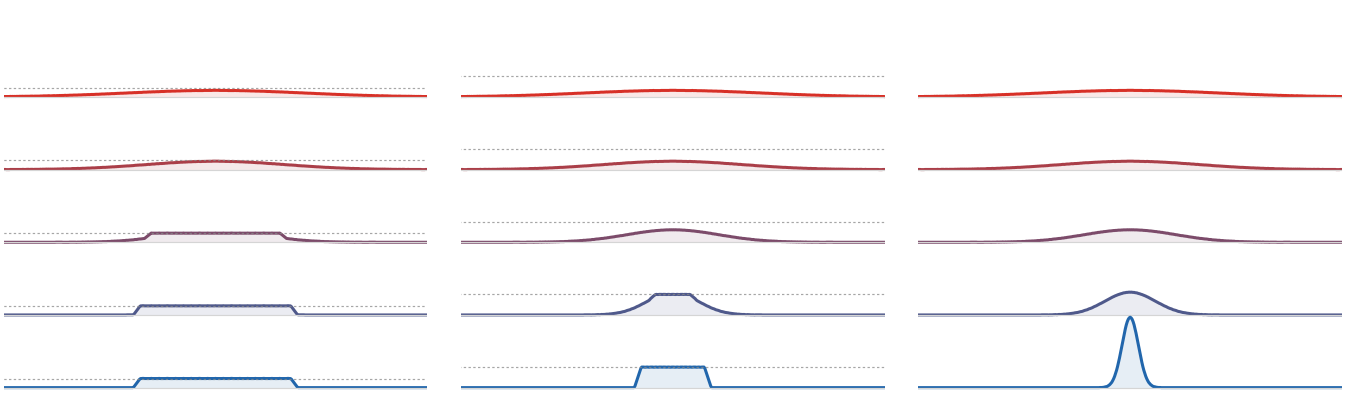

In [4]:
display(Image(filename=str(THUMB)))